In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
df = pd.read_csv('data/ParisHousing_synthetic.csv')
df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,48870,4,1,1,29,31846,1,4,2010,0,1,4602,3150,194,0,8,6507726.20
1,4537,63,1,0,48,79677,4,7,2011,1,0,2871,1562,616,1,7,6945305.57
2,5331,82,0,1,43,19790,8,3,2005,1,1,2556,7696,216,0,10,7593837.35
3,80141,51,0,1,26,55465,9,9,2003,0,1,3411,3347,318,1,9,2739056.82
4,97503,12,1,0,50,85302,9,5,1991,1,0,7681,7801,276,0,9,3077630.12


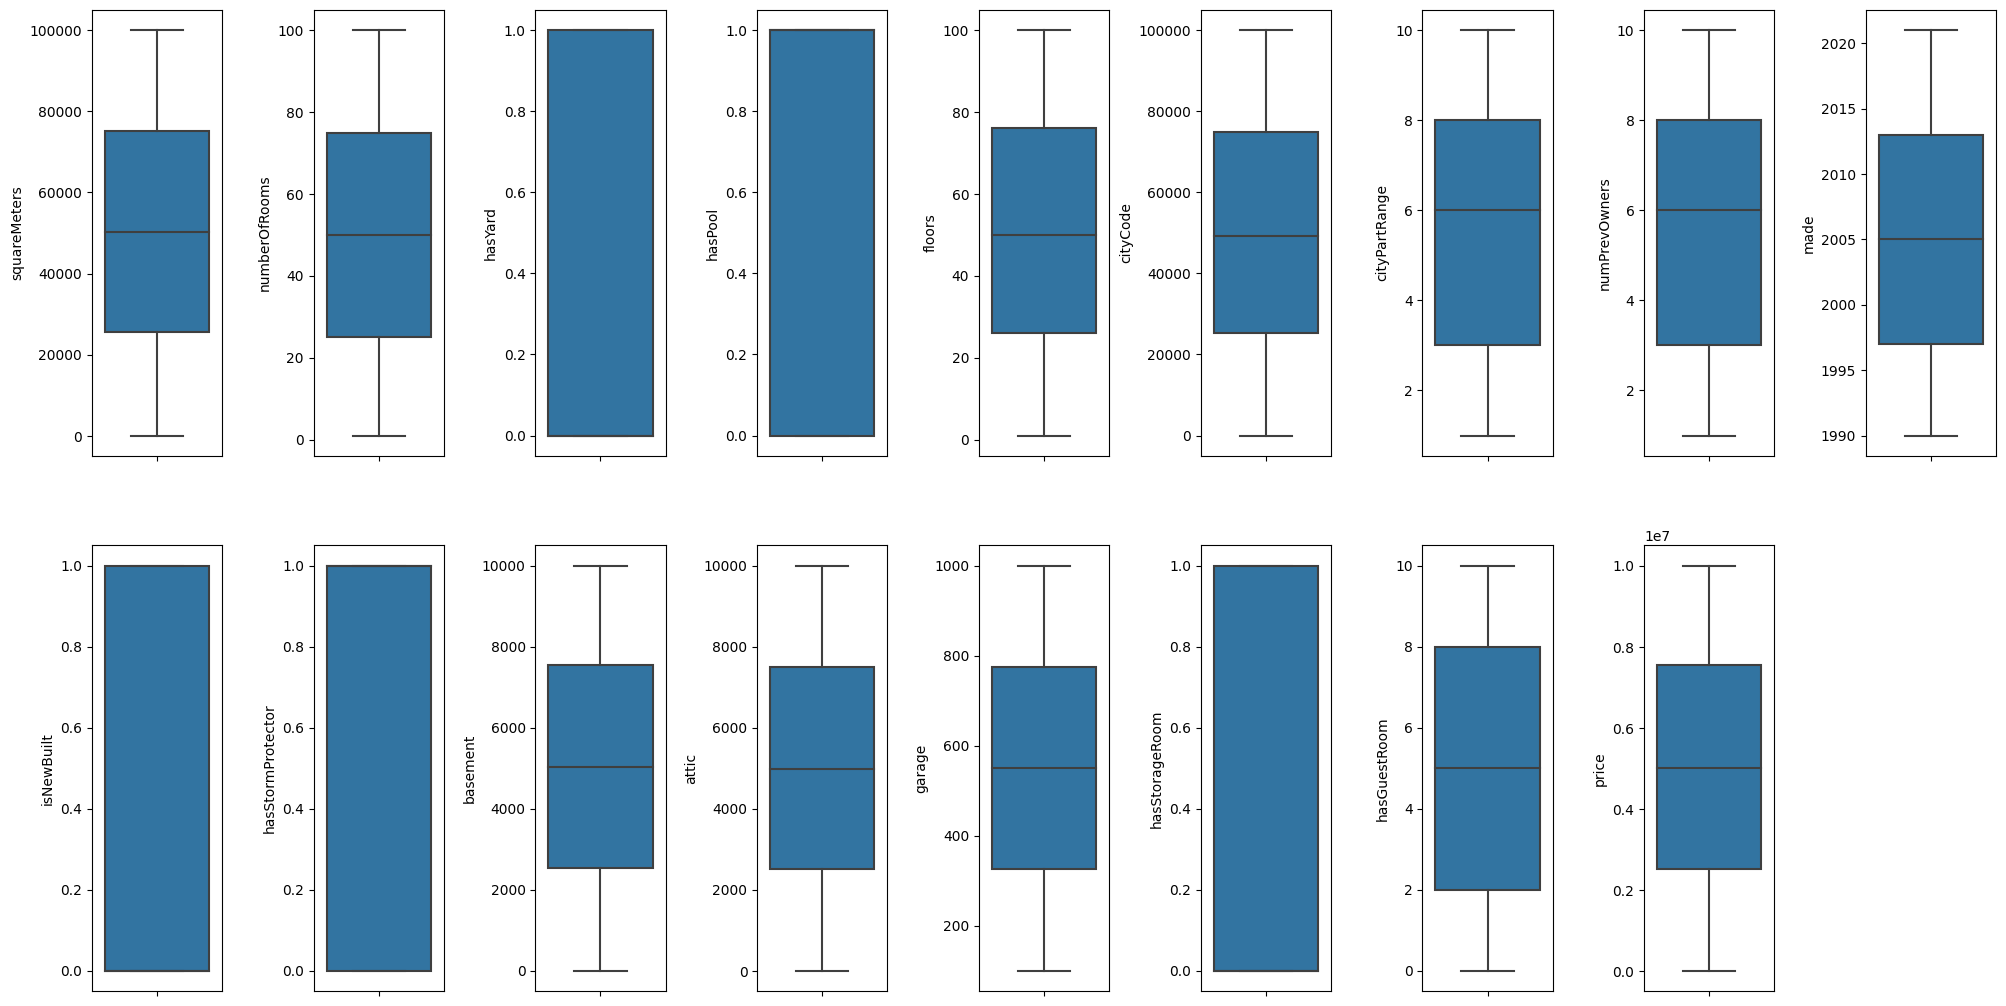

In [3]:
# --- [CELL 2]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# === BEFORE (original) ===
# # create box plots
# fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
# index = 0
# ax = ax.flatten()
# 
# for col, value in df.items():
#     sns.boxplot(y=col, data=df, ax=ax[index])
#     index += 1
# plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)

# === AFTER (edited) ===
n_cols = len(df.columns)
nrows, ncols = 2, int(np.ceil(n_cols / 2))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 10))
ax = np.array(ax).flatten()

for index, col in enumerate(df.columns):
    sns.boxplot(y=col, data=df, ax=ax[index])

# Hide any unused subplot axes
for j in range(n_cols, len(ax)):
    ax[j].set_visible(False)

plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)

In [4]:
import numpy as np
from matplotlib.figure import Figure

assert "df" in globals(), "Expected df from prior cells"
assert "fig" in globals() and "ax" in globals(), "Expected fig and ax from the plotting cell"

assert isinstance(fig, Figure), "Expected a matplotlib Figure"
assert isinstance(ax, np.ndarray), "Expected flattened subplot axes as a numpy array"

axes = ax.ravel()
num_columns = len(df.columns)

# The plotting layout only needs enough slots for all dataframe columns.
assert len(axes) >= num_columns, (
    f"Expected at least {num_columns} subplot axes, got {len(axes)}"
)
assert len(fig.axes) >= num_columns, (
    f"Figure should contain at least {num_columns} axes, got {len(fig.axes)}"
)

# Check that one boxplot-like artist exists on each used axis.
used_axes = axes[:num_columns]
for i, axis in enumerate(used_axes):
    has_artists = len(axis.artists) > 0
    has_lines = len(axis.lines) > 0
    has_patches = len(axis.patches) > 0
    assert has_artists or has_lines or has_patches, (
        f"Axis {i} does not appear to contain a boxplot"
    )

print(f"✓ Passed: plotted {num_columns} columns without exceeding subplot capacity")

✓ Passed: plotted 17 columns without exceeding subplot capacity
